# ⚠️ Important: Run this cell first!

This notebook works in **Google Colab** and **Local environments**.
- In **Colab**: The setup below will automatically clone the repository and prepare all data
- **Locally**: Make sure you're in the `template` directory and have the repository files

Click the ▶️ button below to run the setup!

In [94]:
# ============================================
# Setup: Auto-detect Colab vs Local
# ============================================
# This cell automatically sets up the environment
# It only clones the repository if running in Google Colab
# On local systems, it just shows a warning

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("🚀 Running in Google Colab - Setting up automatically...")
    !git clone https://github.com/ab-zarif-razin/figure-template.git repo
    import os
    os.chdir('/content/repo/template')
    print("✅ Setup complete! All data files are ready.")
else:
    print("⚠️  Running locally - Make sure you're in the 'template' directory!")
    print("📌 For Google Colab: Use the '🔵 Open in Colab' button from the GitHub README")
    print("📌 This notebook requires the repository data files to be in the working directory.")

⚠️  Running locally - Make sure you're in the 'template' directory!
📌 For Google Colab: Use the '🔵 Open in Colab' button from the GitHub README
📌 This notebook requires the repository data files to be in the working directory.


Style Sheet
This cell defines the shared plotting style used throughout the notebook.

It should be placed near the top of the script before creating any figures, so that all plots use the same:
- font family and sizes
- line and marker styling
- axis and tick appearance
- figure resolution
- PDF font settings

It also includes a helper function for adding panel labels to subplots.

In [95]:
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import image as mpimg
import numpy as np
plt.rcdefaults()

# plt.style.use("seaborn-v0_8-colorblind")
# plt.style.use("seaborn-v0_8-deep")
# plt.style.use("seaborn-v0_8-muted")


# Define a consistent style for all figures
plt.rcParams.update({
    "font.family": "sans-serif",
    # "font.sans-serif": ['DejaVu Sans', 'Bitstream Vera Sans', 'Computer Modern Sans Serif', 'Lucida Grande', 'Verdana', 'Geneva', 'Lucid', 'Arial', 'Helvetica', 'Avant Garde', 'sans-serif'],
    # "font.sans-serif": ['DejaVu Sans','TeX Gyre Heros'],
    "font.sans-serif": ['DejaVu Sans', 'TeX Gyre Heros'],
    "font.size": 6,
    "figure.labelsize": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.6,
    "lines.linewidth": 0.6,
    "lines.markersize": 2.0,
    "lines.markeredgewidth": 0.5,
    "errorbar.capsize": 2,
    "patch.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
    "legend.fontsize": 6,
    # "figure.dpi": 300,          
    "pdf.fonttype": 42,
})

def letter_annotation(ax, letter):
    ax.annotate(
        letter,
        xy=(0, 1),
        xycoords='axes fraction',
        xytext=(-20, 6),
        textcoords='offset points',
        ha='right',
        va='bottom',
        fontsize=7,
        fontweight='bold',
        clip_on=False,
    )



Single X and Single Y axis

Line Plot

In [96]:
def drawfigureF(fig):
    # ========================== Loading data from CSV files ===========================================
    x1, y1 = np.loadtxt('singleXsingleY/LinePlot/line_plot_x1_y1.csv', delimiter=',', skiprows=1, unpack=True)
    x2, y2 = np.loadtxt('singleXsingleY/LinePlot/line_plot_x2_y2.csv', delimiter=',', skiprows=1, unpack=True)
    x1_fit, y_fit1 = np.loadtxt('singleXsingleY/LinePlot/line_plot_x1_y1_fit.csv', delimiter=',', skiprows=1, unpack=True)
    x2_fit, y_fit2 = np.loadtxt('singleXsingleY/LinePlot/line_plot_x2_y2_fit.csv', delimiter=',', skiprows=1, unpack=True)
    ax = fig.subplots(1,1)
    ax.plot(x1, y1, 'o', label='Data', markerfacecolor='none',color='C1')
    ax.plot(x1, y_fit1, '-', label='Fit',color='C1')
    ax.plot(x2, y2, 'o', label='Data 2', markerfacecolor='none',color='C2')
    ax.plot(x2, y_fit2, '-', label='Fit 2',color='C2')
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.tick_params(direction='in', top=True, right=True)
    # ax.legend(frameon=False, loc='best')
    ax.text(15, 6.0, 'Signal 1', ha='center', va='center')
    ax.text(15, 1.0, 'Signal 2', ha='center', va='center')
    letter_annotation(ax, 'f')

# drawfigureF(plt.figure(figsize=(4,3)))


Histogram Plot

In [97]:
def drawfigureE(fig):
    # ========================== Loading data from CSV files ===========================================
    x1 = np.loadtxt('singleXsingleY/Histogram/histogram.csv', delimiter=',', skiprows=1, unpack=True)
    def normal_distribution(x, mean, std):
        return (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)
    
    ax = fig.subplots(1,1)

    nbins = 20
    yshift = 0

    ax.hist(x1, bins=nbins, color='C0', alpha=0.5, edgecolor='black')

    y_fit =yshift + x1.shape[0] * (x1.max() - x1.min()) / nbins * normal_distribution(np.linspace(x1.min(), x1.max(), 100), np.mean(x1), np.std(x1))
    ax.plot(np.linspace(x1.min(), x1.max(), 100), y_fit, color='C3')

    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.tick_params(direction='in', top=True, right=True)
    # ax.legend(frameon=False, loc='best')
    letter_annotation(ax, 'e')

# drawfigureE(plt.figure(figsize=(4,3)))

Dual X and Dual Y axis

In [98]:
def drawfigureB(fig):
    
    #------------------------------------ Loading data from CSV files --------------------------------------
    x, y_left, y_right = np.loadtxt('singleXdoubleY/data_singleX_doubleY.csv', delimiter=',', skiprows=1, unpack=True)
    
    axL = fig.subplots(1,1)
    
    #------------------------------- Left Y-axis -----------------------------------------------------------------------
    color = 'C0'
    
    axL.plot(x, y_left, color=color)
    axL.set_xlim(left=-5, right=60)
    # axL.set_ylim()
    axL.set_xlabel("Frequency, $\\omega/2\\pi$ (THz)")
    axL.set_ylabel("$C_v$( $\\mathrm{ J\\,Kg^{-1}\\,K^{-1}\\,THz^{-1}}$ )", color=color)
    axL.text(40, 2.5, 'Spectral \n Heat Capacity', color=color, ha='center', va='center',rotation=0, transform_rotates_text=True)
    
    # Graphic adjustments for left Y-axis (don't edit if you don't know what it does)
    axL.spines['left'].set_color(color)
    axL.tick_params(direction='in', top=True, right=True)
    axL.tick_params(axis='y',colors=color)

    #--------------------------------- Right Y-axis ------------------------------------------------------------------
    axR = axL.twinx()
    color = 'C1'
    
    axR.plot(x, y_right, color=color)
    axR.set_ylabel(" $C_v$ ( $\\mathrm{J\\,Kg^{-1}\\,K^{-1}}$ )", color=color)
    axR.text(40, 380, 'Cumulative \n Heat Capacity', color=color, ha='center', va='center',rotation=0, transform_rotates_text=True)
    
    
    # Graphic adjustments for right Y-axis (don't edit if you don't know what it does)
    axR.spines['left'].set_visible(False)
    axR.spines['right'].set_color(color)
    axR.spines['top'].set_visible(False)
    axR.spines['bottom'].set_visible(False)
    axR.tick_params(colors=color,direction='in',top=False, right=True, left=False, bottom=False)
    
    axL.spines['right'].set_visible(False)
    axL.tick_params(right=False)
    

    #---------------------------------- Top X-axis (comment out if not needed) -----------------------------------------------
    axTop = axL.secondary_xaxis('top', (lambda x: x/0.03, lambda x: x*0.03))
    axTop.set_xlabel("Wavenumber, $\\tilde{\\nu}$ $( \\mathrm{cm^{-1}} )$")
    
    # Graphic adjustments for top X-axis (don't edit if you don't know what it does)
    axL.spines['top'].set_visible(False)
    axTop.tick_params(direction='in')
    axL.tick_params(top=False)  

    #---------------------------------- Letter annotation ------------------------------------------------------

    letter_annotation(axL, 'b')

# drawfigureB(plt.figure(figsize=(4,3)))

Shared X axis plot

In [99]:
def drawfigureC(fig):

    fig.subplots_adjust(hspace=0.05)
    ax1, ax2 = fig.subplots(2,1,sharex=True)

    #============================================= Top figure ======================================================
    x1,y1,y1_err = np.loadtxt('./sharedX/x1_y1_y1err.csv', delimiter=',', skiprows=1, unpack=True)

    ax1.plot(x1, y1, 'o--', label='Data', markerfacecolor='none',color='C0')
    ax1.fill_between(x1, y1-y1_err, y1+y1_err, color='C0', alpha=0.2,linewidth=0)
    ax1.set_ylabel('Thermal Conductivity (Wm$^{-1}$K$^{-1}$)')
    ax1.text(40, 6.0, 'Region 1', ha='center', va='center')
    ax1.tick_params(direction='in', top=True, right=True)

    #============================================= Bottom figure ======================================================
    x2,y2,y2_err = np.loadtxt('./sharedX/x2_y2_y2err.csv', delimiter=',', skiprows=1, unpack=True)

    ax2.plot(x2, y2, 'o--', label='Data', markerfacecolor='none',color='C1')
    ax2.fill_between(x2, y2-y2_err, y2+y2_err, color='C1', alpha=0.2,linewidth=0)
    ax2.set_xlabel('X-axis')
    ax2.set_ylabel('Thermal Conductivity (Wm$^{-1}$K$^{-1}$)')
    ax2.text(35, 25.0, 'Region 2', ha='center', va='center')

    ax2.tick_params(direction='in', top=True, right=True)

    #------------------------- Bottom figure right Y-axis (comment out if not needed) -----------------------------------------------
    x3,y3,y3_err = np.loadtxt('./sharedX/x3_y3_y3err.csv', delimiter=',', skiprows=1, unpack=True)

    ax2R = ax2.twinx()

    color = 'C2'
    ax2R.plot(x3, y3, 'o--', label='Data', markerfacecolor='none',color=color)
    ax2R.fill_between(x3, y3-y3_err, y3+y3_err, color='C2', alpha=0.2,linewidth=0)
    ax2R.set_ylabel('Specific Heat (Jkg$^{-1}$K$^{-1}$)', color=color)
    ax2R.text(85, 200, 'Region 3', color='C2', ha='center', va='center')
    
    # Graphic adjustments for right Y-axis (don't edit if you don't know what it does)
    ax2R.spines['left'].set_visible(False)
    ax2R.spines['right'].set_color(color)
    ax2R.spines['top'].set_visible(False)
    ax2R.spines['bottom'].set_visible(False)
    ax2R.tick_params(colors=color,direction='in',top=False, right=True, left=False, bottom=False)
    ax2.spines['right'].set_visible(False)
    ax2.tick_params(right=False)

    # Letter annotation

    letter_annotation(ax1, 'c')


# drawfigureC(plt.figure(figsize=(3,6)))

Break Plots

In [100]:
def drawfigureA(fig):
    fig.subplots_adjust(hspace=0.05)
    ax1,ax2,ax3 = fig.subplots(3,1,sharex=True)

    #======================================== Top figure ============================================================
    x1,y1,y1_err = np.loadtxt('./breakY/x1_y1_y1err.csv', delimiter=',', skiprows=1, unpack=True)

    ax1.plot(x1, y1, 'o--', label='Data', markerfacecolor='none',color='C0')
    ax1.fill_between(x1, y1-y1_err, y1+y1_err, color='C0', alpha=0.3,linewidth=0)
    # ax1.errorbar(x1, y1, yerr=y1_err, fmt='o--', label='Data', markerfacecolor='none',color='C0')
    ax1.text(175, 10, 'Case 1', ha='center', va='center')
    
    ax1.tick_params(direction='in', top=True, right=True,bottom=False)
    ax1.spines['bottom'].set_visible(False)

    #======================================== Middle figure ============================================================
    x2,y2,y2_err = np.loadtxt('./breakY/x2_y2_y2err.csv', delimiter=',', skiprows=1, unpack=True)

    ax2.plot(x2, y2, 'o--', label='Data', markerfacecolor='none',color='C1')
    ax2.fill_between(x2, y2-y2_err, y2+y2_err, color='C1', alpha=0.3,linewidth=0)
    # ax2.errorbar(x2, y2, yerr=y2_err, fmt='o--', label='Data', markerfacecolor='none',color='C1')
    ax2.text(175, 4.8, 'Case 2', ha='center', va='center',rotation=5, transform_rotates_text=True)
    ax2.tick_params(direction='in', top=False, right=True,bottom=False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    #======================================== Bottom figure ============================================================
    x3,y3,y3_err = np.loadtxt('./breakY/x3_y3_y3err.csv', delimiter=',', skiprows=1, unpack=True)

    ax3.plot(x3, y3, 'o--', label='Data', markerfacecolor='none',color='C2')
    ax3.fill_between(x3, y3-y3_err, y3+y3_err, color='C2', alpha=0.3,linewidth=0)
    # ax3.errorbar(x3, y3, yerr=y3_err, fmt='o--', label='Data', markerfacecolor='none',color='C2')
    ax3.set_xlabel('X-axis')
    fig.supylabel('Y-axis')
    ax3.set_ylim(0,1)
    ax3.text(175, 0.7, 'Case 3', ha='center', va='center',rotation=0, transform_rotates_text=True)
    ax3.tick_params(direction='in', top=False, right=True)
    ax3.spines['top'].set_visible(False)

    # drawing break points
    d = 0.75  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=5,
                linestyle="none", color='k', mec='k', mew=1, clip_on=False)

    ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

    ax2.plot([0,1], [0, 0], transform=ax2.transAxes, **kwargs)
    ax3.plot([0,1], [1,1], transform=ax3.transAxes, **kwargs)

    # letter annotation
    letter_annotation(ax1, 'a')
# drawfigureA(plt.figure(figsize=(3,6)))

Schematic Diagram

In [101]:
def drawfigureD(fig):
    ax = fig.subplots(1,1)
    img = mpimg.imread('./dummy_schematic_diagram.png')
    ax.imshow(img)
    ax.axis('off')  # Hide axes
    letter_annotation(ax, 'd')
# drawfigureD(plt.figure(figsize=(2,3.0)))

Figure Panel

/tmp/ipykernel_1046/815243229.py:2: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.05)
/tmp/ipykernel_1046/2894729049.py:3: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.05)


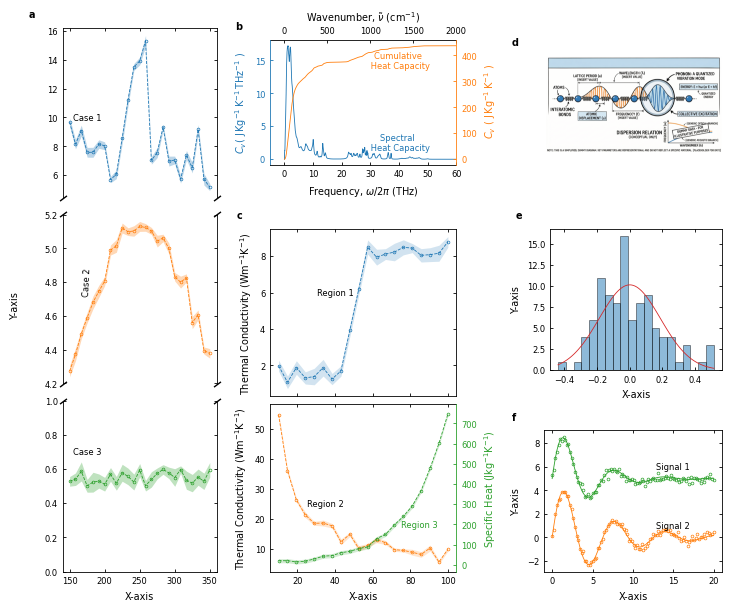

In [103]:
#==================== Layout 1 ============================================
figpanel = plt.figure(figsize=(7.2,6.0),constrained_layout=True)
gs = GridSpec(nrows=3, ncols=3, figure=figpanel,width_ratios=[0.8,1,0.8])
subfigA = figpanel.add_subfigure(gs[:, 0])
subfigB = figpanel.add_subfigure(gs[0, 1])
subfigC = figpanel.add_subfigure(gs[1:, 1])
subfigD = figpanel.add_subfigure(gs[0, 2])
subfigE = figpanel.add_subfigure(gs[1, 2])
subfigF = figpanel.add_subfigure(gs[2, 2])

drawfigureA(subfigA)
drawfigureB(subfigB)
drawfigureC(subfigC)
drawfigureD(subfigD)
drawfigureE(subfigE)
drawfigureF(subfigF)

#===================== Layout 2 (uncomment to use)===============================================
# figpanel = plt.figure(figsize=(7.2,4.5),constrained_layout=True)
# gs = GridSpec(nrows=2, ncols=3, figure=figpanel,width_ratios=[1,1,1])
# subfigA = figpanel.add_subfigure(gs[:, 0])
# subfigC = figpanel.add_subfigure(gs[:, 1])
# subfigE = figpanel.add_subfigure(gs[0, 2])
# subfigB = figpanel.add_subfigure(gs[1, 2])

# drawfigureA(subfigA)
# drawfigureB(subfigB)
# drawfigureC(subfigC)
# drawfigureE(subfigE)

#-------------- Uncomment the following lines if you want to save the figure -------------------------------------
# plt.savefig('./fig_panel_final.png', dpi=300,bbox_inches='tight')
# plt.savefig('./fig_panel_final.pdf',format='pdf',bbox_inches='tight')
plt.show()